# 07 · De les successions als límits de funcions

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/07_Limits_Continuitat.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Interpretar límits laterals, la definició ε–δ i la continuïtat abans de derivar.

**Abans de començar:** quaderns 05–06 i funcions elementals  
**Temps orientatiu:** 1–2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Quadern nou de transició al càlcul diferencial.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Canviar només un punt de la gràfica pot canviar el límit?

**Al final ho has de poder explicar:** Llegir límits laterals i separar el valor d'una funció del valor al qual s'apropa.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Apropar-se al punt per camins diferents
Per a $x\ne1$, $f(x)=(x^2-1)/(x-1)=x+1$. Encara que f no estigui definida a 1,
els valors s'apropen a 2 quan x s'apropa a 1. El límit descriu el comportament
**a prop del punt**, no necessàriament el valor en el punt.

Calcula mentalment què passarà amb les successions $x_n=1+1/n$ i $y_n=1-1/n$.


In [2]:
n = np.array([2, 10, 100, 1000, 10000])
for k, dreta, esquerra in zip(n, 2+1/n, 2-1/n):
    print(f"n={k:5d}: f(1+1/n)≈{dreta:.6f}; f(1-1/n)≈{esquerra:.6f}")
print("Hem usat l'expressió simplificada x+1 per evitar cancel·lació numèrica.")


n=    2: f(1+1/n)≈2.500000; f(1-1/n)≈1.500000
n=   10: f(1+1/n)≈2.100000; f(1-1/n)≈1.900000
n=  100: f(1+1/n)≈2.010000; f(1-1/n)≈1.990000
n= 1000: f(1+1/n)≈2.001000; f(1-1/n)≈1.999000
n=10000: f(1+1/n)≈2.000100; f(1-1/n)≈1.999900
Hem usat l'expressió simplificada x+1 per evitar cancel·lació numèrica.


## Laboratori animat · observa, atura i explica


### Dos viatgers s'acosten al mateix lloc

A l'esquerra definim $f(x)=x+1$ per a $x\ne1$ i $f(1)=3$.
El viatger blau ve de l'esquerra ($x=1-h$) i el taronja de la dreta ($x=1+h$), amb $h>0$.
Les altures són $2-h$ i $2+h$: totes dues s'apropen a 2. El punt ple $(1,3)$ és el valor
assignat a la funció i **no es mou**. El cercle buit $(1,2)$ indica el forat.

A la dreta, $g(x)=-1$ si $x<0$ i $g(x)=1$ si $x\ge0$. Els viatgers s'acosten a 0,
però mantenen altures diferents. Aquest és un salt, no un forat que puguem omplir amb un sol valor.

| h | f(1−h) | f(1+h) | g(−h) | g(h) |
|---|---|---|---|---|
| 0,1 | 1,9 | 2,1 | −1 | 1 |
| 0,01 | 1,99 | 2,01 | −1 | 1 |

**Prediu** la fila h=0,001. **Pausa** i identifica, per separat, el límit esquerre,
el límit dret i el valor en el punt. No els dedueixis només del punt ple.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "Apropar-se a un punt: un forat i un salt"
fotogrames_laboratori = list(range(18))

def estat_limits(pas):
    h = .8*(.72**pas)
    return h, 2-h, 2+h, -1.0, 1.0

def dibuixa_laboratori(pas, axes):
    h, esquerre, dret, ge, gd = estat_limits(pas)
    ax, bx = axes
    x = np.linspace(0, 2, 300)
    ax.plot(x, x+1, color="0.5")
    ax.scatter([1], [2], facecolor="white", edgecolor="0.2", s=85, zorder=6)
    ax.scatter([1], [3], color="#7c3aed", s=60, label="f(1) = 3", zorder=5)
    for xx, yy, color in [(1-h, esquerre, "#2563eb"), (1+h, dret, "#ea580c")]:
        ax.scatter(xx, yy, color=color, s=65, zorder=5)
        ax.plot([xx, xx], [0, yy], ":", color=color)
    ax.axhline(2, ls="--", color="#047857", label="Límit: 2")
    ax.set(xlim=(0, 2), ylim=(0, 3.5), xlabel="x", ylabel="f(x)",
           title=f"Forat: h = {h:.5f}\nf(1−h) = {esquerre:.5f}; f(1+h) = {dret:.5f}")
    ax.legend(loc="lower right", fontsize=8)
    bx.plot([-1, 0], [-1, -1], color="0.5")
    bx.plot([0, 1], [1, 1], color="0.5")
    bx.scatter([0], [-1], facecolor="white", edgecolor="0.2", s=85, zorder=6)
    bx.scatter([0], [1], color="#7c3aed", s=60, zorder=6)
    bx.scatter([-h, h], [ge, gd], color=["#2563eb", "#ea580c"], s=65, zorder=5)
    bx.set(xlim=(-1, 1), ylim=(-1.5, 1.5), xlabel="x", ylabel="g(x)",
           title="Salt: límit esquerre −1; límit dret 1\nNo existeix el límit bilateral a 0")


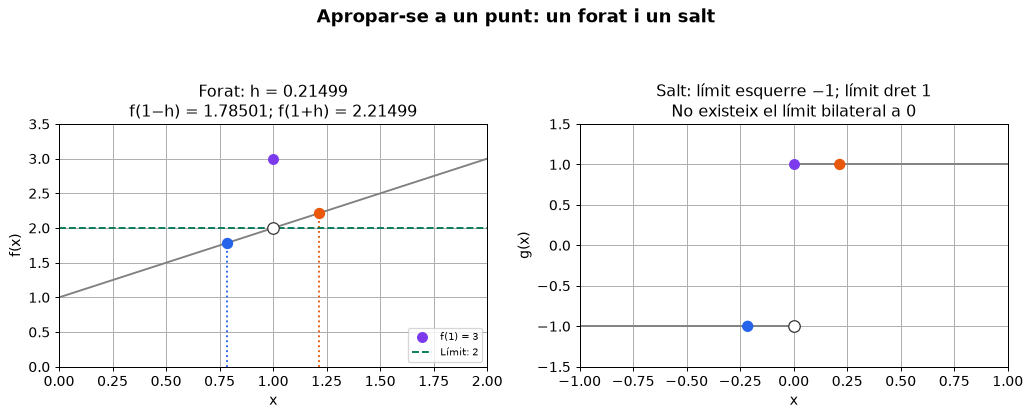

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(4)


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara una aproximació inicial i una d'avançada. En el forat, les dues altures s'acosten a 2 encara que f(1)=3. En el salt, les altures continuen separades: anota les tres dades, límit esquerre, límit dret i valor al punt.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (0, 10)
etiquetes_comparacio = [f"h = {.8*.72**k:.5f}" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Si f(x)=x+1 per a x≠1 i f(1)=3, quin és el límit quan x→1?', 'opcions': ['3', 'No existeix', '2'], 'correcta': 2, 'retorn': ["3 és el valor al punt, no el valor al qual s'apropen les imatges properes.", 'Les dues aproximacions laterals tendeixen a 2; el forat no impedeix el límit.', 'Correcte: per a x≠1, f(x)−2=x−1, que tendeix a 0.']}, {'enunciat': 'Canviar només g(0) pot reparar un salt amb límits laterals −1 i 1?', 'opcions': ['No', 'Sí, posant g(0)=0', 'Sí, posant g(0)=1'], 'correcta': 0, 'retorn': ['Correcte: canviar un punt no canvia els límits laterals diferents.', 'Posar el punt al mig del salt no fa que els dos costats arribin a la mateixa altura.', "Coincidir amb el costat dret no resol el desacord amb l'esquerre."]}, {'enunciat': "Per fer contínua la funció del forat a 1, quin valor hem d'assignar a f(1)?", 'opcions': ['Qualsevol', '2', '3'], 'correcta': 1, 'retorn': ['La continuïtat exigeix igualtat entre el valor al punt i el límit.', 'Correcte: el límit és 2, així que f(1) també ha de ser 2.', "Amb f(1)=3, el punt ple continua separat de l'altura límit."]}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


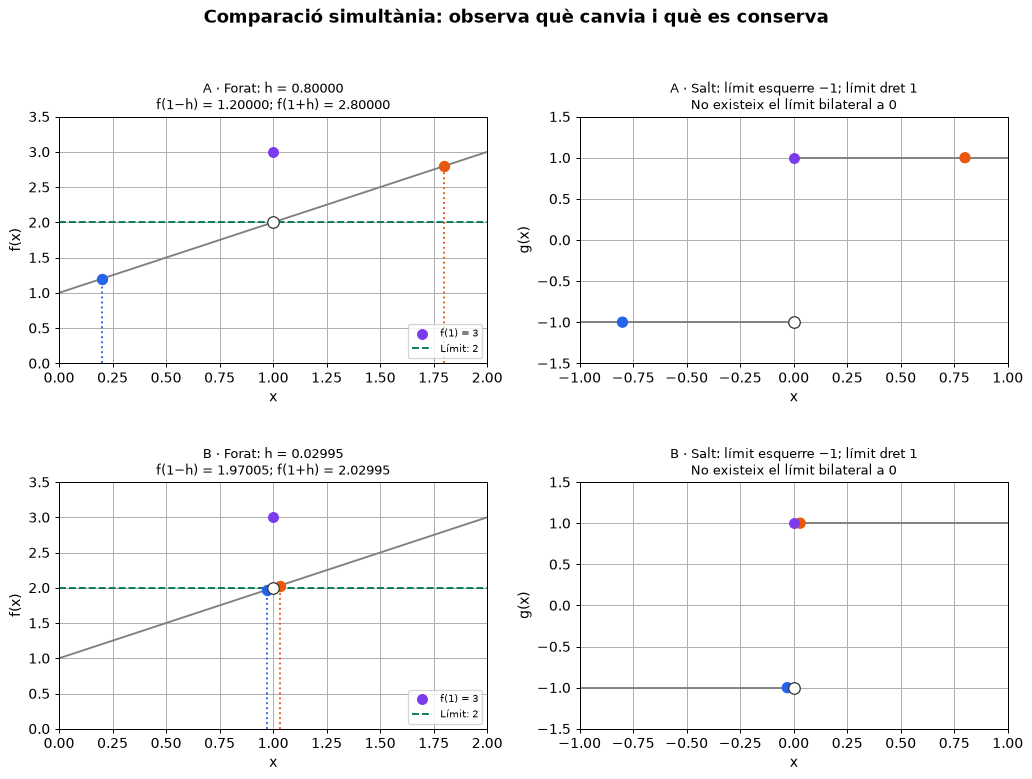

interactive(children=(Dropdown(description='Estat A:', options=(('h = 0.80000', 0), ('h = 0.57600', 1), ('h = …

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Canvia només el valor assignat f(1). Comprova amb una taula si les aproximacions per l'esquerra i la dreta canvien. Després explica per què f(1)=2 repara la continuïtat i altres valors no.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


In [10]:
valor_en_el_punt = 3  # Torna a executar amb 2 i després amb -1.
def funcio_amb_forat(x):
    return valor_en_el_punt if x == 1 else x+1
print("f(1) =", funcio_amb_forat(1))
for exponent in range(1, 6):
    h = 10.0**(-exponent)
    print(f"h={h:.5f}; f(1−h)={funcio_amb_forat(1-h):.5f}; "
          f"f(1+h)={funcio_amb_forat(1+h):.5f}")
print("La fórmula x+1 per a x≠1 justifica el límit 2.")
print("Contínua a 1:", valor_en_el_punt == 2)


f(1) = 3
h=0.10000; f(1−h)=1.90000; f(1+h)=2.10000
h=0.01000; f(1−h)=1.99000; f(1+h)=2.01000
h=0.00100; f(1−h)=1.99900; f(1+h)=2.00100
h=0.00010; f(1−h)=1.99990; f(1+h)=2.00010
h=0.00001; f(1−h)=1.99999; f(1+h)=2.00001
La fórmula x+1 per a x≠1 justifica el límit 2.
Contínua a 1: False


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Si f(x)=x+1 per a x≠1 i f(1)=3, quin és el límit quan x→1?**

- A. 3
- B. No existeix
- C. 2

**2. Canviar només g(0) pot reparar un salt amb límits laterals −1 i 1?**

- A. No
- B. Sí, posant g(0)=0
- C. Sí, posant g(0)=1

**3. Per fer contínua la funció del forat a 1, quin valor hem d'assignar a f(1)?**

- A. Qualsevol
- B. 2
- C. 3

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Si canviem només f(1) de 3 a 2, què canvia: els límits laterals, el límit bilateral o la continuïtat?
2. Podem fer contínua g a 0 canviant només g(0)? Justifica-ho amb els dos costats.
3. Per a f i una tolerància vertical 0,01, quina distància horitzontal al punt 1 és suficient?
   Explica-ho primer amb paraules i després amb $|x-1|$ i $|f(x)-2|$.
4. Trobar dues successions que tendeixen a la mateixa altura prova sempre que existeix el límit?
   Què permeten concloure dues successions amb altures límit diferents?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

Només canvia la continuïtat: amb f(1)=2, la funció és contínua.
El salt de g no es repara canviant un sol punt. Si $0<|x-1|<0{,}01$, llavors
$|f(x)-2|=|x-1|<0{,}01$. Dues successions concordants no proven el límit per a tots
els camins; dues amb límits diferents sí que el refuten.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. La definició ε–δ · Ampliació formal
$$\lim_{x\to a}f(x)=L\quad\Longleftrightarrow\quad
\forall\varepsilon>0\ \exists\delta>0\ \forall x\text{ del domini}:\quad
0<|x-a|<\delta\Rightarrow|f(x)-L|<\varepsilon.$$
El 0< exclou el punt a. Per a $f(x)=x+1$, a=1 i L=2,
$|f(x)-2|=|x-1|$, de manera que δ=ε serveix per a tots els punts del domini.


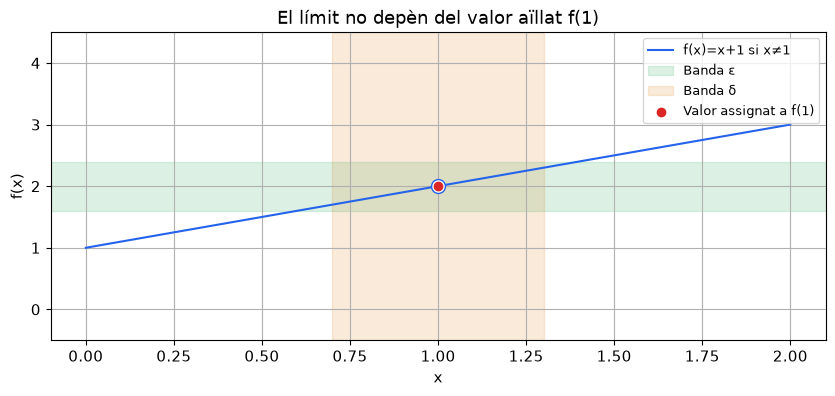

La implicació per a TOTS els punts és vàlida si δ≤ε: True
La funció és contínua a 1 si f(1)=2: True


interactive(children=(FloatSlider(value=0.4, description='epsilon', max=1.0, min=0.05, step=0.05), FloatSlider…

In [13]:
def bandes(epsilon=.4, delta=.3, valor_punt=2.0):
    fig, ax = plt.subplots()
    x = np.linspace(0, 2, 401)
    ax.plot(x, x+1, color="#2563eb", label="f(x)=x+1 si x≠1")
    ax.axhspan(2-epsilon, 2+epsilon, color="#16a34a", alpha=.15, label="Banda ε")
    ax.axvspan(1-delta, 1+delta, color="#d97706", alpha=.15, label="Banda δ")
    ax.scatter([1], [2], facecolors="white", edgecolors="#2563eb", s=100, zorder=4)
    ax.scatter([1], [valor_punt], color="#dc2626", zorder=5, label="Valor assignat a f(1)")
    ax.set(xlabel="x", ylabel="f(x)", ylim=(-.5, 4.5), title="El límit no depèn del valor aïllat f(1)")
    ax.legend(fontsize=9); plt.show()
    print("La implicació per a TOTS els punts és vàlida si δ≤ε:", delta <= epsilon)
    print("La funció és contínua a 1 si f(1)=2:", valor_punt == 2)
panell = explora(bandes, epsilon=(.05, 1., .05), delta=(.05, 1., .05), valor_punt=(0., 4., .5))


## 3. Dos límits laterals diferents impedeixen el límit
Considerem $g(x)=-1$ si x<0 i $g(x)=1$ si x≥0.
Les successions $1/n$ i $-1/n$ tendeixen a 0, però les imatges tendeixen a 1 i −1.
Per tant g no té límit a 0.

**Criteri seqüencial:** el límit és L si per a **tota** successió $x_n$ del domini,
amb $x_n\ne a$ i $x_n\to a$, tenim $f(x_n)\to L$.
Dues successions amb resultats diferents refuten el límit; dues amb el mateix
resultat, totes soles, no el demostren.


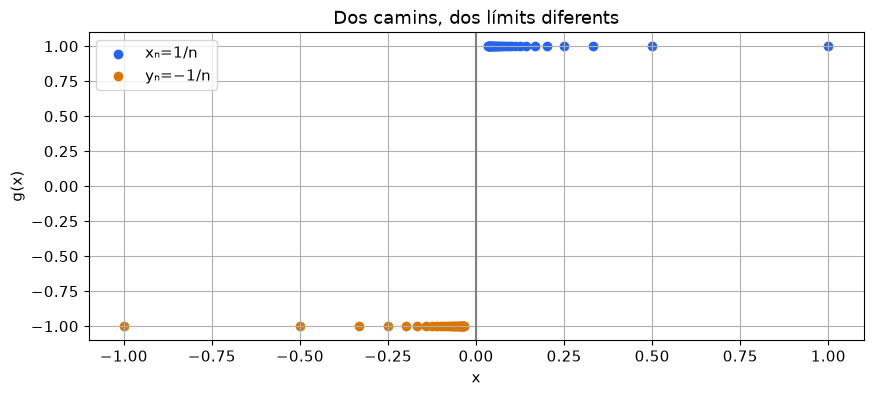

In [14]:
n = np.arange(1, 31)
fig, ax = plt.subplots()
ax.scatter(1/n, np.ones_like(n), color="#2563eb", label="xₙ=1/n")
ax.scatter(-1/n, -np.ones_like(n), color="#d97706", label="yₙ=−1/n")
ax.axvline(0, color="0.5"); ax.set(xlabel="x", ylabel="g(x)", title="Dos camins, dos límits diferents")
ax.legend(); plt.show()


## 4. Continuïtat
f és contínua a a si està definida a a i $\lim_{x\to a}f(x)=f(a)$.
A la funció inicial, assignar f(1)=2 omple el forat de manera contínua;
assignar f(1)=3 no canvia el límit, però produeix una discontinuïtat.

## Activitats
1. Per a ε=0,01, dona un δ vàlid per a $f(x)=x+1$ al punt 1.
2. **Ampliació:** per a $f(x)=x^2$ al punt 1, prova
   $|x^2-1|=|x-1||x+1|<3|x-1|$ si $|x-1|<1$.
   Justifica δ=min(1, ε/3).
3. Si f(1)=3 a l'exemple inicial, quin és el límit? És contínua?
4. Explica per què provar únicament una successió de punts no estableix un límit de funció.

<details><summary>Comprovació</summary>

δ=0,01 serveix. Si $|x-1|<1$, tenim $0<x<2$ i $|x+1|<3$.
El límit continua sent 2 quan f(1)=3, i la funció no és contínua a 1.
</details>


**Navegació:** [Anterior](06_Completesa_R.ipynb) · [Índex i guia](README.md) · [Següent](Derivades_BAT.ipynb)
